In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.insert(0, '../src')

from simcore.common.data_logger import DataLogger

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True

In [11]:
# --- Config ---
TRIAL_PATH = '../log/experimental'   # change to your trial

# Load all bundles
bundles = DataLogger.load_all(TRIAL_PATH)

print(f"Found bundles: {list(bundles.keys())}")
for name, data in bundles.items():
    signals = [k for k in data.keys() if k != 'timestamps']
    print(f"  {name}: {len(data['timestamps'])} samples | signals: {signals}")

# Helper — relative timestamps in seconds
def t(bundle):
    ts = bundle['timestamps']
    return ts - ts[0]

Found bundles: ['box', 'target', 'arm', 'ctrl_arm', 'table']
  box: 665 samples | signals: ['pos', 'q', 'qd', 'qdd', 'quat']
  target: 665 samples | signals: ['pos', 'quat']
  arm: 665 samples | signals: ['base_pos', 'base_quat', 'ctrl', 'q', 'qd', 'qdd', 'tau']
  ctrl_arm: 670 samples | signals: ['Fff', 'cartesian_mass', 'f_ext', 'f_internal', 'mode', 'q', 'q_target', 'qd', 'tau', 'tau_gravity', 'x_current', 'x_target', 'xd_current', 'xd_target']
  table: 665 samples | signals: ['pos', 'quat']


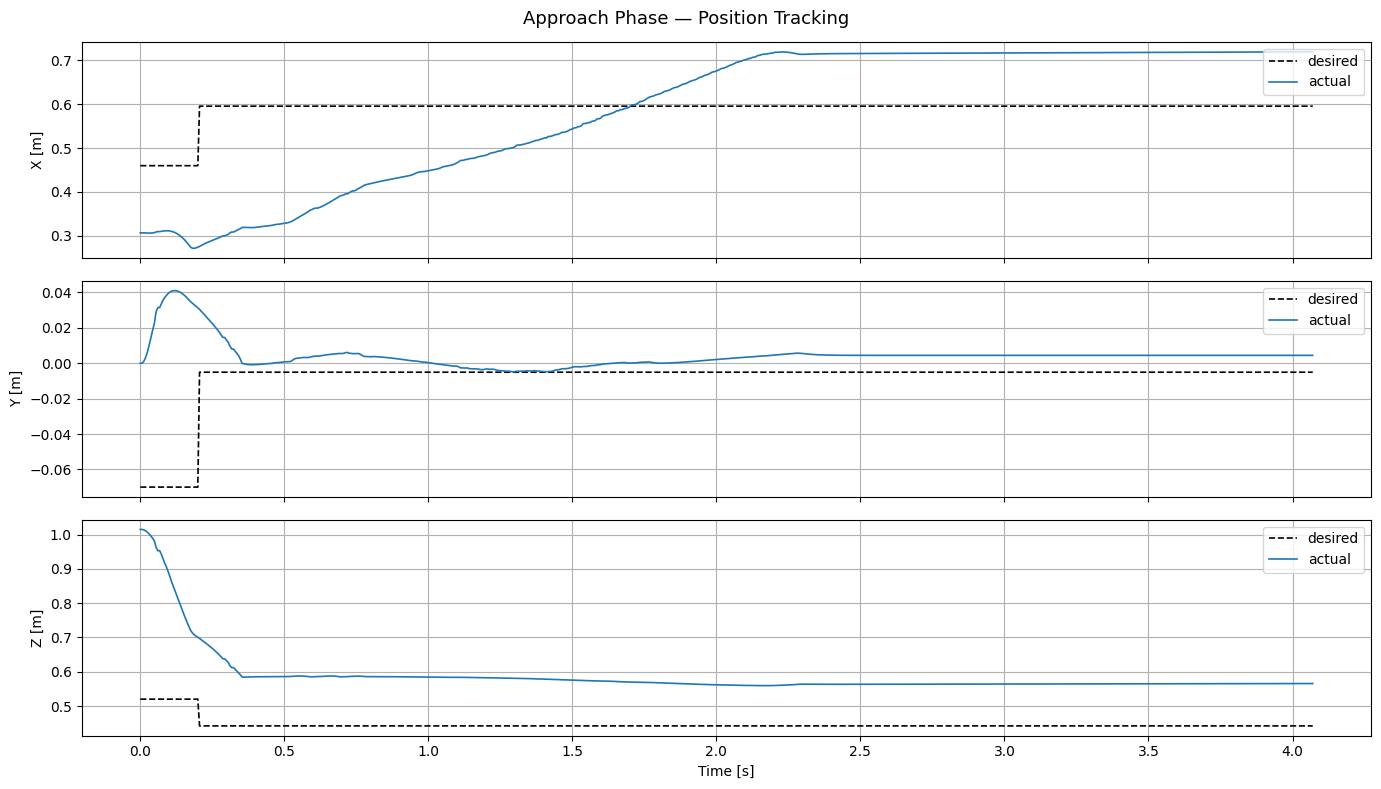

In [12]:
ctrl = bundles['ctrl_arm']
time = t(ctrl)

x_target  = np.array(ctrl['x_target'])   # (N, 7) — pos(3) + quat(4)
x_current = np.array(ctrl['x_current'])  # (N, 7) — pos(3) + quat(4)
p_des = x_target[:, :3]
p_act = x_current[:, :3]

labels = ['X', 'Y', 'Z']
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Approach Phase — Position Tracking', fontsize=13)

for i, ax in enumerate(axes):
    ax.plot(time, p_des[:, i], 'k--', label='desired', linewidth=1.2)
    ax.plot(time, p_act[:, i], label='actual', linewidth=1.2)
    ax.set_ylabel(f'{labels[i]} [m]')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()

In [9]:
box = bundles['box']
print(box["pos"])

[[ 0.5        -0.05        0.425     ]
 [ 0.5        -0.05        0.43185883]
 [ 0.5        -0.05        0.43847241]
 [ 0.5        -0.05        0.44484074]
 [ 0.5        -0.05        0.45096382]
 [ 0.5        -0.05        0.45684164]
 [ 0.5        -0.05        0.46247422]
 [ 0.5        -0.05        0.46786155]
 [ 0.5        -0.05        0.47300363]
 [ 0.5        -0.05        0.47790046]
 [ 0.5        -0.05        0.48255204]
 [ 0.5        -0.05        0.48695837]
 [ 0.5        -0.05        0.49111945]
 [ 0.5        -0.05        0.49503528]
 [ 0.5        -0.05        0.49870586]
 [ 0.5        -0.05        0.50213118]
 [ 0.5        -0.05        0.50531126]
 [ 0.5        -0.05        0.50824609]
 [ 0.5        -0.05        0.51093567]
 [ 0.5        -0.05        0.51338   ]
 [ 0.5        -0.05        0.51557908]
 [ 0.5        -0.05        0.51753291]
 [ 0.5        -0.05        0.51924149]
 [ 0.5        -0.05        0.52070482]
 [ 0.5        -0.05        0.52192289]
 [ 0.5        -0.05      